In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

df = pd.read_csv("10_employees_vs_revenue.csv")

print("First 5 rows:")
print(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

First 5 rows:
  num_employees marketing_spend_usd competitor_price_usd season_index  \
0            81               70.79                54.15            3   
1           177              313.39                46.67            2   
2            85              364.09                58.21          NaN   
3           182              394.15                 7.31            3   
4            30              411.92                 6.01            3   

   revenue_thousand_usd  
0                1278.0  
1                2204.0  
2                1392.0  
3                2203.0  
4                 362.0  

Shape of dataset:
(308, 5)

Columns:
Index(['num_employees', 'marketing_spend_usd', 'competitor_price_usd',
       'season_index', 'revenue_thousand_usd'],
      dtype='object')

Data types:
num_employees            object
marketing_spend_usd      object
competitor_price_usd     object
season_index             object
revenue_thousand_usd    float64
dtype: object

Missing values:
num_empl

In [2]:
# Convert required columns to numeric

df["num_employees"] = pd.to_numeric(
    df["num_employees"], errors="coerce"
)

df["revenue_thousand_usd"] = pd.to_numeric(
    df["revenue_thousand_usd"], errors="coerce"
)

# Remove missing values

df = df.dropna(
    subset=["num_employees", "revenue_thousand_usd"]
)

# Create binary target using median revenue

median_revenue = df["revenue_thousand_usd"].median()

df["revenue_class"] = (
    df["revenue_thousand_usd"] >= median_revenue
).astype(int)

print("Median Revenue:", median_revenue)

print("\nBinary Target:")
print(df["revenue_class"].value_counts())

print("\nDataset:")
print(df[[
    "num_employees",
    "revenue_thousand_usd",
    "revenue_class"
]].head())

Median Revenue: 1278.0

Binary Target:
revenue_class
1    148
0    146
Name: count, dtype: int64

Dataset:
   num_employees  revenue_thousand_usd  revenue_class
0           81.0                1278.0              1
1          177.0                2204.0              1
2           85.0                1392.0              1
3          182.0                2203.0              1
4           30.0                 362.0              0


In [3]:
# Input feature

X = df[["num_employees"]]

# Binary target variable

y = df["revenue_class"]

print("Input Feature:")
print(X.columns.tolist())

print("\nTarget Variable:")
print("revenue_class")

# Split dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining data shape:")
print(X_train.shape)

print("\nTesting data shape:")
print(X_test.shape)

Input Feature:
['num_employees']

Target Variable:
revenue_class

Training data shape:
(235, 1)

Testing data shape:
(59, 1)


In [4]:
# Build Linear Regression model

model = LinearRegression()

# Train the model

model.fit(X_train, y_train)

# Generate predictions

y_pred = model.predict(X_test)

print("Raw continuous predictions:")
print(y_pred[:10])

print("\nModel Coefficient:")
print(model.coef_)

print("\nModel Intercept:")
print(model.intercept_)

Raw continuous predictions:
[0.4868684  0.48593582 0.49712672 0.48852631 0.49837015 0.50210045
 0.49204937 0.50199683 0.49370728 0.49826654]

Model Coefficient:
[0.00010362]

Model Intercept:
0.48386343390472014


In [6]:
# Classification threshold

threshold = 0.5

# Convert continuous predictions into class labels

y_pred_class = (y_pred >= threshold).astype(int)

# Calculate accuracy

accuracy = accuracy_score(
    y_test,
    y_pred_class
)

print("Classification Threshold:", threshold)

print("\nPredicted Classes:")
print(y_pred_class[:10])

print("\nActual Classes:")
print(y_test.values[:10])

print("\nAccuracy:")
print(accuracy)

Classification Threshold: 0.5

Predicted Classes:
[0 0 0 0 0 1 0 1 0 0]

Actual Classes:
[0 0 1 0 1 1 0 1 0 1]

Accuracy:
0.6779661016949152


C:\Users\chait\miniconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


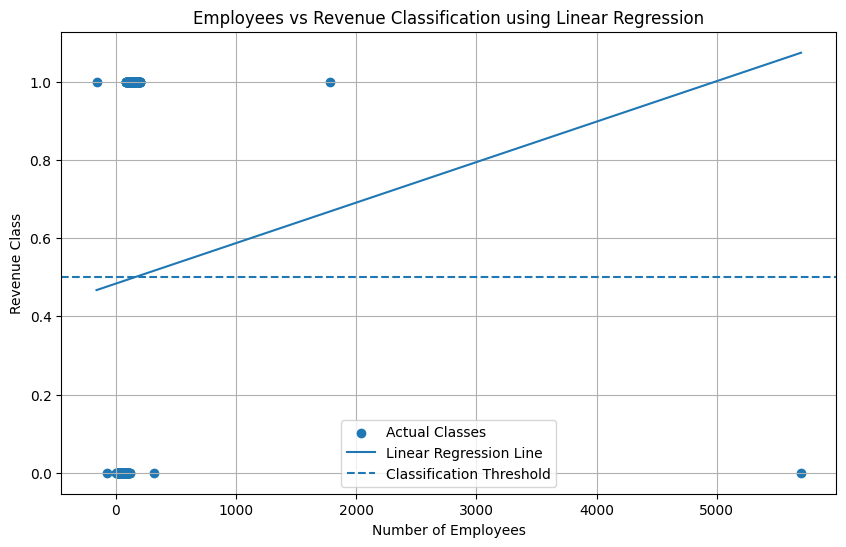

In [7]:
# Create values for regression line

X_line = np.linspace(
    X["num_employees"].min(),
    X["num_employees"].max(),
    100
).reshape(-1, 1)

y_line = model.predict(X_line)

plt.figure(figsize=(10, 6))

# Actual observations

plt.scatter(
    X["num_employees"],
    y,
    label="Actual Classes"
)

# Linear Regression line

plt.plot(
    X_line,
    y_line,
    label="Linear Regression Line"
)

# Classification threshold

plt.axhline(
    y=threshold,
    linestyle="--",
    label="Classification Threshold"
)

plt.xlabel("Number of Employees")
plt.ylabel("Revenue Class")
plt.title("Employees vs Revenue Classification using Linear Regression")

plt.legend()
plt.grid(True)

plt.show()

In [8]:
# Change classification threshold

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

print("Threshold Comparison:\n")

for threshold in thresholds:

    y_pred_class = (
        y_pred >= threshold
    ).astype(int)

    accuracy = accuracy_score(
        y_test,
        y_pred_class
    )

    print(
        "Threshold:",
        threshold,
        "Accuracy:",
        accuracy
    )

Threshold Comparison:

Threshold: 0.3 Accuracy: 0.5254237288135594
Threshold: 0.4 Accuracy: 0.5254237288135594
Threshold: 0.5 Accuracy: 0.6779661016949152
Threshold: 0.6 Accuracy: 0.4745762711864407
Threshold: 0.7 Accuracy: 0.4745762711864407


In [9]:
# New observation

new_observation = pd.DataFrame({
    "num_employees": [150]
})

# Raw continuous prediction

raw_prediction = model.predict(
    new_observation
)[0]

# Final class using threshold

threshold = 0.5

final_class = int(
    raw_prediction >= threshold
)

print("New Observation:")
print(new_observation)

print("\nRaw Prediction:")
print(raw_prediction)

print("\nClassification Threshold:")
print(threshold)

print("\nFinal Class:")
print(final_class)

if final_class == 1:
    print("Interpretation: High Revenue")
else:
    print("Interpretation: Low Revenue")

New Observation:
   num_employees
0            150

Raw Prediction:
0.49940634898005976

Classification Threshold:
0.5

Final Class:
0
Interpretation: Low Revenue


In [ ]:
print("Limitations of Linear Regression for Binary Classification:")
print()
print("1. Linear Regression produces continuous output values.")
print("2. Predictions can be less than 0 or greater than 1.")
print("3. A classification threshold must be manually selected.")
print("4. The predicted values are not probabilities.")
print("5. Accuracy can change when the classification threshold changes.")
print()
print("Why Logistic Regression is preferred:")
print("Logistic Regression is specifically designed for binary classification.")
print("It produces probability values between 0 and 1.")
print("A classification threshold can then be used to assign class labels.")